In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import rasterio as rio

## Grab reference data

In [49]:
ground_data_folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/'
# os.listdir(ground_data_folder)

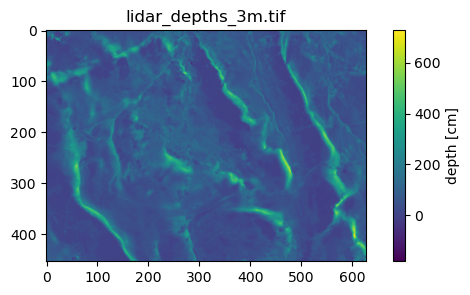

In [69]:
fname = 'lidar_depths_3m.tif'
file = rio.open(ground_data_folder+fname) # open
lidar_DATA = file.read(1) # read in the first and only band (elevations)

grid_X = np.arange(file.bounds.left+1.5, file.bounds.right,3)
grid_Y = np.arange(file.bounds.top,file.bounds.bottom,-3)

# plot
plt.figure(figsize=(7,3)); plt.imshow(lidar_DATA); plt.title(fname); 
cbar = plt.colorbar(); cbar.set_label('depth [cm]'); plt.show()

## Grab radar otuputs

In [124]:
rd_array_path = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedMay25_xyz/' # to rd arrays
rd_output_path = '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/' # to output csv files

/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd33_1000scale_100size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd11_800scale_100size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd7_1000scale_100size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd22_800scale_200size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd14_800scale_100size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd9_800scale_200size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd25_1000scale_100size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd19_800scale_100size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd29_1000scale_100size_1mod.csv nee

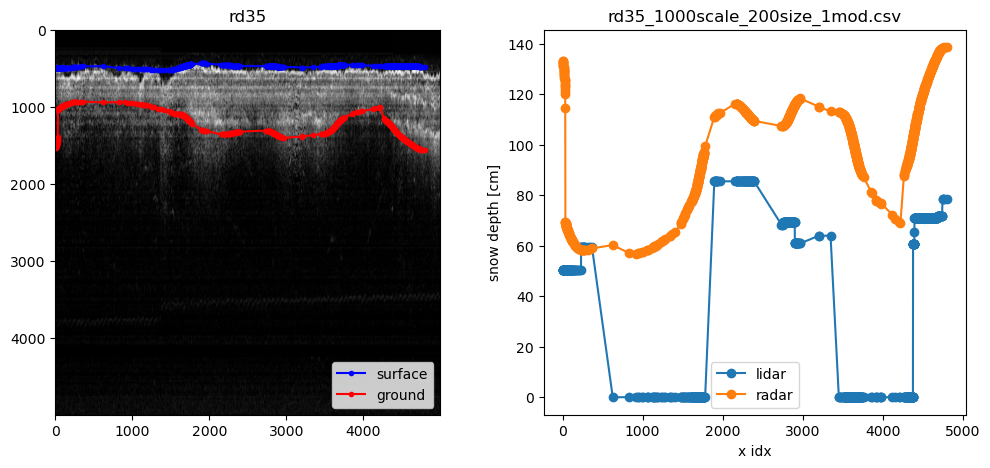

/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd2_800scale_100size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd33_1000scale_200size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd16_1000scale_200size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd31_800scale_200size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd20_800scale_200size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd15_1000scale_100size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd28_1000scale_200size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd23_1000scale_200size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd26_1000scale_200size_0.5mod.

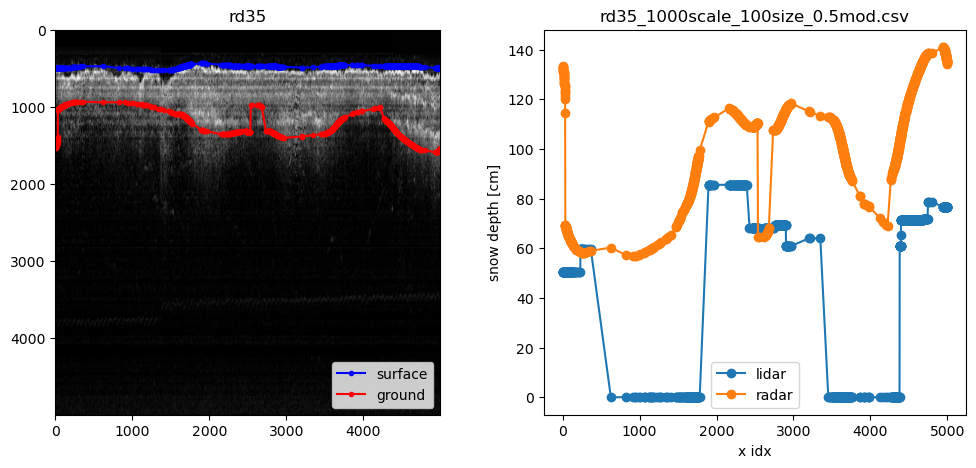

/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd29_800scale_100size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd16_800scale_100size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd20_800scale_200size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd4_1000scale_100size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd9_800scale_100size_1mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd11_1000scale_100size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd2_800scale_100size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd22_1000scale_200size_0.5mod.csv needs to be rerun.
/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd29_800scale_100size_0.5mod.csv

In [125]:
# grab files
rd_output_files = glob.glob(rd_output_path+'*')
for file in rd_output_files:
    # if '1000scale' in file and '200size' in file and '1mod' in file:
    if file.endswith('.csv'):
    # if file == rd_output_path+'rd35_1000scale_200size_1mod.csv':
        coords_df = pd.read_csv(file)
        if len(coords_df.columns) < 7: # if the columns do not contain Isurf, Iground, x_idx
            print(file+' needs to be rerun.')
        else:
            rd_id = file.split('/')[-1].split('_')[0]
            rd = np.load(glob.glob(rd_array_path+rd_id+'_preprocessed.npy')[0])
    
            # find nearest idxs for radar point data
            x_idxs = []; y_idxs = []
            for i in range(0, len(coords_df.x)):
                x = coords_df.x[i]; y = coords_df.y[i]
            
                x_idxs.append(np.argmin(np.abs(grid_X-x)))
                y_idxs.append(np.argmin(np.abs(grid_Y-y)))
            lidar_depths = lidar_DATA[y_idxs, x_idxs].flatten()
    
            # VISUALIZE THE DATA IN COMPARISON WITH REFERENCE DATA
            fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
            im1 = ax1.imshow(rd,cmap='Greys_r') # plot radargram
            ax1.plot(coords_df.x_idx, coords_df.Isurf, 'b.-')
            ax1.plot(coords_df.x_idx, coords_df.Iground, 'r.-')
            ax1.legend(['surface','ground'],loc='lower right')
            ax1.set_title(rd_id)
    
            ax2.plot(coords_df.x_idx,lidar_depths,'o-')
            ax2.plot(coords_df.x_idx, coords_df.depth/2,'o-')
            ax2.set_title(file.split('/')[-1])
            ax2.set_ylabel('snow depth [cm]'); ax2.set_xlabel('x idx')
            ax2.legend(['lidar','radar'])
            # plt.ylim(5000,0)
            plt.show()
    
            # PROMPT FOR MANUAL INTERVENTION
            # SELECT SECTION ON RD TO REMOVE
            # REPLOT RD WITH DATA REMOVED, DEPTH COMPARISON, AND 1 to 1 PLOT WITH FILTERED DATA IN BLACK

4